# Harmonic Oscillator

In [1]:
import wave_packet_dynamics as wpd

In [2]:
# create a 1 dimensional grid with bounds x_min and x_max
# the grid contains a finite number of points with even spacing
x_min = -3
x_max = 3
bounds = (x_min, x_max)
points = 3001
grid = wpd.Grid(bounds, points)

In [3]:
import wpd.wave_functions as wave
import wpd.potential_functions as pot

from functools import partial

# create a gaussian wave function with width 0.25 at initial x coordinate 1
# the particle has no initial momentum, meaning its initial wavenumber is 0
gaussian_function = partial(wave.gaussian, sigma=0.25, x0=1, k0=0)
wave_function = wpd.WaveFunction(grid, gaussian_function)

# create a parabola potential with force constant 10^2 centered at x coordinate 0
harmonic_function = partial(pot.harmonic, k=1*10**2, x0=0)
potential = wpd.Potential(grid, harmonic_function)

Starting simulation:
Writing data from time step 1000 to file
Adding data from time step 1000 to animation
Deleting animation!
Simulation finished!


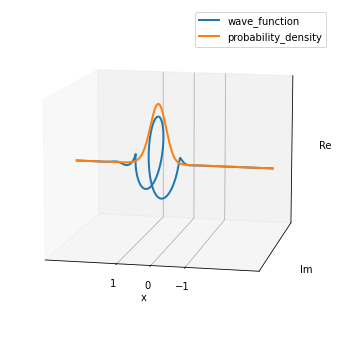

In [4]:
# create a simulation object
# provide a grid, wave function, potential and the time increment
# an optional name for the simulation can be added
dt = 2*10**-3
simulation = wpd.Simulation(grid, wave_function, potential, dt, "documentation")

# start the simulation by calling the instance
# provide the total number of time steps and optional keyword arguments
# -> take a look at the other examples for possible options
tn = 1000
simulation(tn, animate_step=tn,
           data_to_animate=["wave_function", "probability_density"],
           y_limits=(-2, 2), z_limits=(-2, 2), x_ticks=[-1, 0, 1],
           write_step=tn, data_to_write=["wave_function"],
           value_to_write=["integrated_density"])

# videos consisting only of 1 frame or less are deleted
# however the last frame of the animation is shown in jupyter notebook
# only the specified data and expectation values of the last timestep
# are written to a file by default